# v5.0 normalisation — PURE-S3M BENCHMARK

Same structure as `sorcha_v5_normalisation_s3m.ipynb` but using the benchmark parquet (`outputs/phase2_benchmark_s3m/benchmark_comparison_s3m.parquet`). Benchmark = 475k synthetic 2-det X05 tracklets, S3M objects propagated to 2026-01-01, scored against the same 667 GMM maps. Kernel: `neofast_py310`.

In [2]:
import sys, re, glob
sys.path.insert(0, "adam_core_stub"); sys.path.insert(0, "src")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, precision_recall_curve
import velocity_density_pipeline_gmm as vdp
%matplotlib inline

df_all = pd.read_parquet("outputs/phase2_benchmark_s3m/benchmark_comparison_s3m.parquet")

# Keep only objects scoreable by VDP: must fall within a map magnitude bin.
# 90% of benchmark NEOs have mean_mag~28 (fainter than Rubin's ~24.5 limit) and
# get mag_bin_label=None → P_NEO_vdp=0 by construction. Sorcha naturally excluded
# these; the benchmark did not. This filter makes the comparison fair.
df = df_all[df_all.mag_bin_label.notna()].copy()

if "P_NEO_vdp_unmasked" not in df.columns:
    df["P_NEO_vdp_unmasked"] = df["P_NEO_vdp"]

df["aligned"] = df["population"]
y = df.population.values == "NEO"
df["absdlon"] = df.dlon_from_antisun_deg.abs()

print(f"All objects: {len(df_all):,}  →  scoreable (mag_bin_label != None): {len(df):,}")
print("population counts (scoreable):", df.population.value_counts().to_dict())
print("NEO median P_vdp:", round(df[y].P_NEO_vdp.median(), 3),
      " digest2:", round(df[y].P_NEO_d2.median(), 3))

All objects: 475,027  →  scoreable (mag_bin_label != None): 178,398
population counts (scoreable): {'Trojans': 67857, 'TNO': 48158, 'MBA': 44777, 'NEO': 17606}
NEO median P_vdp: 1.0  digest2: 0.99


## 1. Map P(NEO): support mask

Antisun map, mask OFF vs ON. Mask zeroes non-NEO density in pure-NEO wing cells.

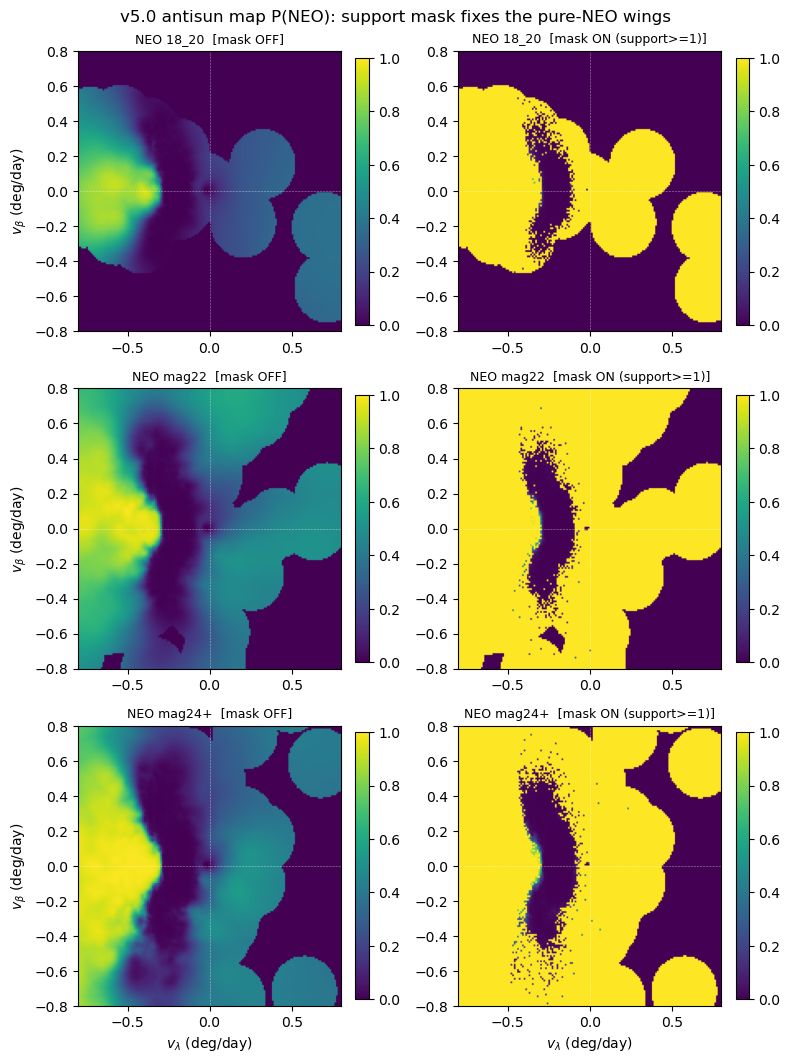

In [3]:
MAP = "prob_maps_grid_s3m/prob_maps_grid_dlon+000_lat+00.npz"   # antisun centre
pm0 = vdp.ProbMapSet.from_npz(MAP)                      # mask OFF
pm1 = vdp.ProbMapSet.from_npz(MAP, support_mask_min=1)  # mask ON

def clip08(pm, M, lim=0.8):
    s = np.abs(pm.x_grid) <= lim; i0, i1 = np.where(s)[0][[0, -1]]
    return M[i0:i1 + 1, i0:i1 + 1]
EXT = [-0.8, 0.8, -0.8, 0.8]

labs = ["18_20", "mag22", "mag24+"]
fig, ax = plt.subplots(len(labs), 2, figsize=(8, 3.6 * len(labs)))
for r, L in enumerate(labs):
    for c, (pm, t) in enumerate([(pm0, "mask OFF"), (pm1, "mask ON (support>=1)")]):
        M = clip08(pm, pm.get_probability_map(L, "NEO"))
        im = ax[r, c].imshow(M, origin="lower", extent=EXT, vmin=0, vmax=1, aspect="auto")
        ax[r, c].set_title(f"NEO {L}  [{t}]", fontsize=9)
        ax[r, c].axhline(0, color="w", lw=.4, ls=":"); ax[r, c].axvline(0, color="w", lw=.4, ls=":")
        plt.colorbar(im, ax=ax[r, c], fraction=.046)
        if c == 0: ax[r, c].set_ylabel(r"$v_\beta$ (deg/day)")
        if r == len(labs) - 1: ax[r, c].set_xlabel(r"$v_\lambda$ (deg/day)")
fig.suptitle("v5.0 antisun map P(NEO): support mask fixes the pure-NEO wings")
plt.tight_layout(); plt.show()

## 1b. S3M kNN vs new GMM grid

P(NEO) and log density: old S3M-kNN antisun map (left) vs new v5.0 GMM grid, mask ON (right).

S3M ref center=(221,0) grid +/-1.5
GMM grid center=(100,0) grid +/-2.0


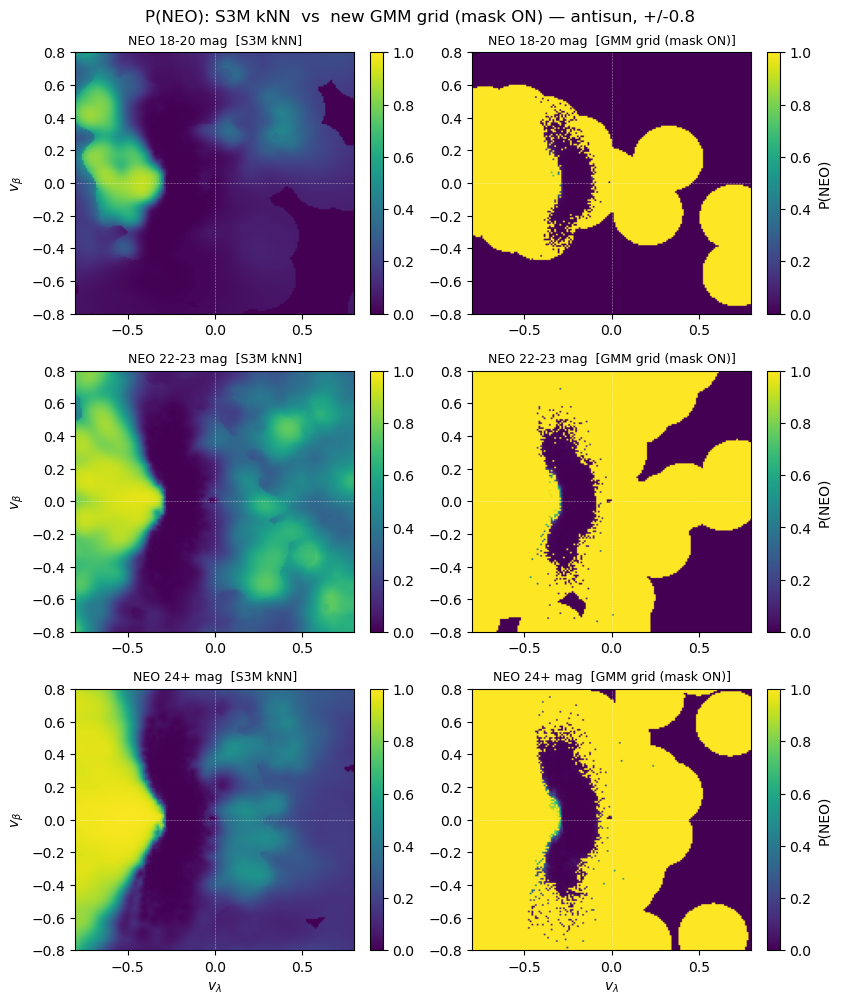

In [4]:
s3m = vdp.ProbMapSet.from_npz(sorted(glob.glob("prob_maps/*antisun*.npz"))[0])  # S3M-kNN reference
gmm = pm1                                                                       # new GMM grid (mask ON)
print(f"S3M ref center=({s3m.center_lon_deg:.0f},{s3m.center_lat_deg:.0f}) grid +/-{s3m.x_grid[-1]:.1f}")
print(f"GMM grid center=({gmm.center_lon_deg:.0f},{gmm.center_lat_deg:.0f}) grid +/-{gmm.x_grid[-1]:.1f}")
_LBL = {"18_20": "18-20", "mag22": "22-23", "mag24+": "24+"}

# P(NEO): S3M vs new GMM 
fig, ax = plt.subplots(len(labs), 2, figsize=(8.5, 3.4 * len(labs)))
for r, b in enumerate(labs):
    for c, (pm, t) in enumerate([(s3m, "S3M kNN"), (gmm, "GMM grid (mask ON)")]):
        M = clip08(pm, pm.get_probability_map(b, "NEO"))
        im = ax[r, c].imshow(M, origin="lower", extent=EXT, vmin=0, vmax=1, aspect="auto")
        ax[r, c].set_title(f"NEO {_LBL[b]} mag  [{t}]", fontsize=9)
        ax[r, c].axhline(0, color="w", lw=.4, ls=":"); ax[r, c].axvline(0, color="w", lw=.4, ls=":")
        plt.colorbar(im, ax=ax[r, c], fraction=.046, label="P(NEO)" if c == 1 else None)
        if c == 0: ax[r, c].set_ylabel(r"$v_\beta$")
        if r == len(labs) - 1: ax[r, c].set_xlabel(r"$v_\lambda$")
fig.suptitle("P(NEO): S3M kNN  vs  new GMM grid (mask ON) — antisun, +/-0.8")
plt.tight_layout(); plt.show()

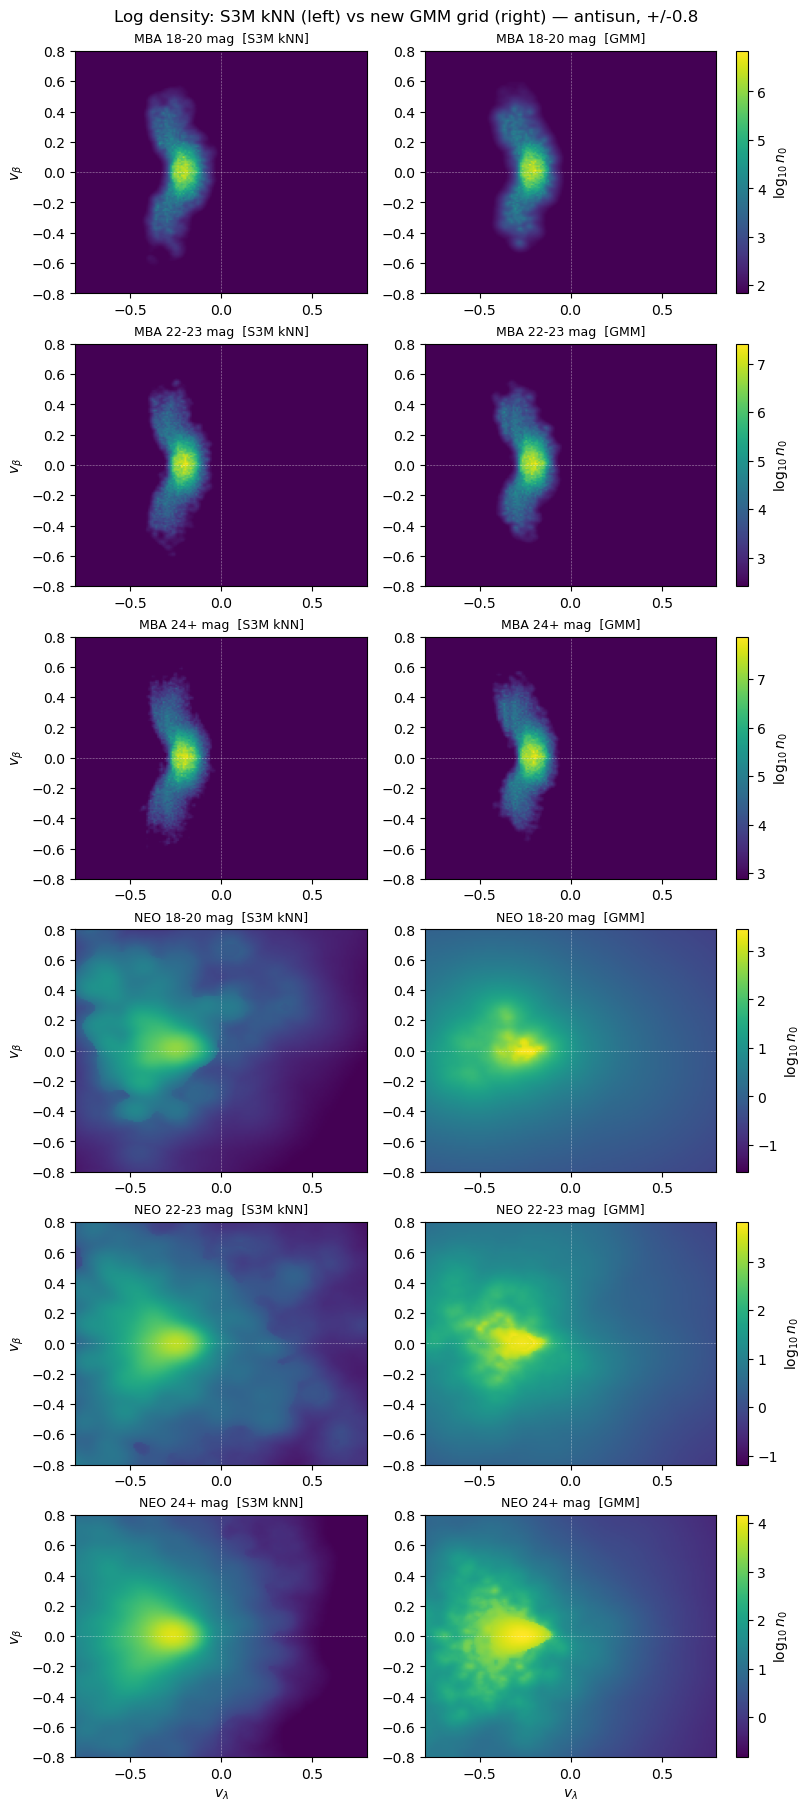

In [5]:
# log density (6 rows): MBA x3 mag, NEO x3 mag, S3M vs new GMM 
rows = [("MBA", "18_20"), ("MBA", "mag22"), ("MBA", "mag24+"),
        ("NEO", "18_20"), ("NEO", "mag22"), ("NEO", "mag24+")]
fig, ax = plt.subplots(len(rows), 2, figsize=(8, 3.0 * len(rows)), constrained_layout=True)
for r, (pop, b) in enumerate(rows):
    Ds = clip08(s3m, s3m.results[b]["density_maps_downweighted_raw"][pop])
    Dg = clip08(gmm, gmm.results[b]["density_maps_downweighted_raw"][pop])
    Ls = np.log10(np.where(Ds > 0, Ds, np.nan)); Lg = np.log10(np.where(Dg > 0, Dg, np.nan))
    vmax = np.nanmax([np.nanmax(Ls), np.nanmax(Lg)]); vmin = vmax - 5   # 5-decade range below peak
    im = None
    for c, (Lm, t) in enumerate([(Ls, "S3M kNN"), (Lg, "GMM")]):
        im = ax[r, c].imshow(Lm, origin="lower", extent=EXT, vmin=vmin, vmax=vmax, aspect="auto", cmap="viridis")
        ax[r, c].set_title(f"{pop} {_LBL[b]} mag  [{t}]", fontsize=9)
        ax[r, c].axhline(0, color="w", lw=.4, ls=":"); ax[r, c].axvline(0, color="w", lw=.4, ls=":")
        if c == 0: ax[r, c].set_ylabel(r"$v_\beta$")
        if r == len(rows) - 1: ax[r, c].set_xlabel(r"$v_\lambda$")
    fig.colorbar(im, ax=ax[r, :].tolist(), fraction=0.025, pad=0.02, label=r"$\log_{10} n_0$")
fig.suptitle("Log density: S3M kNN (left) vs new GMM grid (right) \u2014 antisun, +/-0.8", fontsize=12)
plt.show()

*Note: MBA panel differences between left/right are not a GMM effect — different epoch, clone counts, and training catalog between the two maps.*

## 2. Calibration

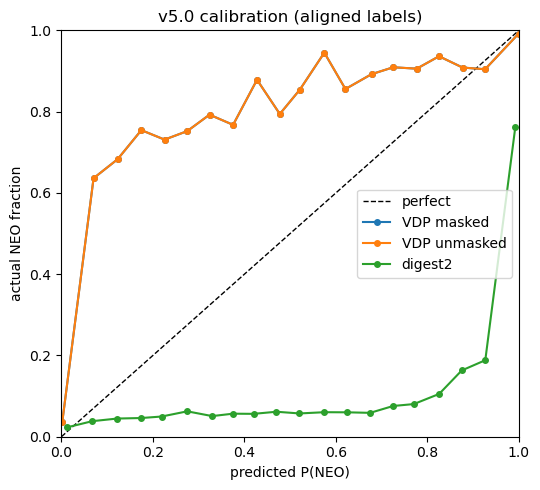

In [6]:
def reliability(score, nbins=20):
    edges = np.linspace(0, 1, nbins + 1)
    idx = np.clip(np.digitize(np.clip(score, 0, 1), edges) - 1, 0, nbins - 1)
    xs, ys = [], []
    for b in range(nbins):
        m = idx == b
        if m.sum() >= 50: xs.append(score[m].mean()); ys.append(y[m].mean())
    return np.array(xs), np.array(ys)

plt.figure(figsize=(5.5, 5))
plt.plot([0, 1], [0, 1], "k--", lw=1, label="perfect")
for name, s in [("VDP masked", df.P_NEO_vdp), ("VDP unmasked", df.P_NEO_vdp_unmasked), ("digest2", df.P_NEO_d2)]:
    xs, ys = reliability(s.values); plt.plot(xs, ys, "o-", ms=4, label=name)
plt.xlabel("predicted P(NEO)"); plt.ylabel("actual NEO fraction")
plt.xlim(0, 1); plt.ylim(0, 1); plt.legend(); plt.title("v5.0 calibration (aligned labels)")
plt.tight_layout(); plt.show()

## 3. ROC, best-F1, per-population, and the antisun-distance breakdown

In [7]:
def roc(name, s):
    s = s.to_numpy(); auc = roc_auc_score(y, s)
    p, r, t = precision_recall_curve(y, s)
    f1 = np.divide(2 * p * r, p + r, out=np.zeros_like(p), where=(p + r) > 0)
    bi = int(np.argmax(f1[:-1])); th = t[bi]; sel = s >= th
    compl = (sel & y).sum() / y.sum(); contam = (sel & ~y).sum() / max(sel.sum(), 1)
    print(f"  {name:16s} AUC={auc:.3f}  bestF1={f1[bi]:.3f}@{th:.3f}  compl={100*compl:.1f}%  contam={100*contam:.1f}%")
    return th

print("=== full-sky ROC (benchmark parquet, NEO=positive) ===")
tv = roc("VDP (masked)", df.P_NEO_vdp)
_  = roc("VDP (unmasked)", df.P_NEO_vdp_unmasked)
td = roc("digest2", df.P_NEO_d2)

print("\nper-population fraction above best-F1 threshold:")
print(f"{'population':>9} {'N':>9} {'VDP%':>7} {'d2%':>7}")
for pop in ['NEO', 'MBA', 'Trojans', 'TNO']:
    m = df.aligned == pop
    print(f"{pop:>9} {int(m.sum()):>9,} {100*(df.P_NEO_vdp[m]>=tv).mean():>7.1f} {100*(df.P_NEO_d2[m]>=td).mean():>7.1f}")

print("\nVDP vs digest2 best-F1 by |dlon| from antisun:")
for lo, hi in [(0,20),(20,40),(40,70),(70,110),(110,141)]:
    m = ((df.absdlon>=lo)&(df.absdlon<hi)).to_numpy()
    if y[m].sum() < 20: continue
    def bf(s): p,r,t=precision_recall_curve(y[m], s[m]); f=np.divide(2*p*r,p+r,out=np.zeros_like(p),where=(p+r)>0); return f[:-1].max()
    print(f"  {lo:>3}-{hi:<3} N={m.sum():>8,}  VDP F1={bf(df.P_NEO_vdp.values):.3f}  d2 F1={bf(df.P_NEO_d2.values):.3f}")

=== full-sky ROC (benchmark parquet, NEO=positive) ===
  VDP (masked)     AUC=0.884  bestF1=0.787@0.019  compl=70.9%  contam=11.7%
  VDP (unmasked)   AUC=0.884  bestF1=0.787@0.019  compl=70.9%  contam=11.7%
  digest2          AUC=0.861  bestF1=0.667@0.970  compl=57.4%  contam=20.4%

per-population fraction above best-F1 threshold:
population         N    VDP%     d2%
      NEO    17,606    70.9    57.4
      MBA    44,777     2.1     0.0
  Trojans    67,857     0.0     0.1
      TNO    48,158     1.4     5.3

VDP vs digest2 best-F1 by |dlon| from antisun:
    0-20  N=  16,701  VDP F1=0.854  d2 F1=0.706
   20-40  N=  18,235  VDP F1=0.803  d2 F1=0.750
   40-70  N=  50,017  VDP F1=0.750  d2 F1=0.799
   70-110 N=  67,835  VDP F1=0.760  d2 F1=0.620
  110-141 N=  25,610  VDP F1=0.842  d2 F1=0.667


## 4. Summary

- Full-sky benchmark results (run cells above to populate).
- Benchmark should show VDP ≥ digest2 if the pipeline is correct — this is the controlled test.

## 5. Direction comparison maps

Density and P(NEO) at four antisun offsets (Δλ = 0°, −40°, −90°, −120°), support mask ON, mag 21–22 / 22–23 / 24–25.

In [8]:

import matplotlib as mpl
_VEL_LIM = (-0.8, 0.8)

def _density_cmap():
    cm = mpl.colormaps["viridis"].copy(); cm.set_bad("0.88"); return cm

def _density_log_map(d):
    d = np.asarray(d, float); pos = np.isfinite(d) & (d > 0)
    lm = np.ma.masked_all(d.shape, float)
    if pos.any():
        lm[pos] = np.log10(d[pos]); vmax = float(np.nanmax(lm)); vmin = vmax - 5.0
    else:
        vmin, vmax = 0.0, 1.0
    return lm, vmin, vmax

def _annotate_no_support(ax, data):
    if np.ma.isMaskedArray(data) and np.ma.count(data) == 0:
        ax.text(0.5, 0.5, "no support", transform=ax.transAxes,
                ha="center", va="center", fontsize=10, color="0.25")

def _mbd(l):
    return {"18_20": "18-20", "mag20": "20-21", "mag21": "21-22", "mag22": "22-23", "mag23": "23-24", "mag24+": "24-25"}.get(l, l)

def _clip(pm, M, lim=0.8):
    s = np.abs(pm.x_grid) <= lim; i0, i1 = np.where(s)[0][[0, -1]]
    return M[i0:i1 + 1, i0:i1 + 1]

def _dir_map_data(pm, pop, b, mode):
    if mode == "density":
        return _density_log_map(_clip(pm, pm.results[b]["density_maps_downweighted_raw"][pop]))[0]
    return _clip(pm, pm.get_probability_map(b, pop))

# four antisun-relative direction maps from the new GMM grid (support mask ON)
DIRS = {"Anti-Sun (dlon=0)": "prob_maps_grid_dlon+000_lat+00.npz",
        "Anti-Sun -40 deg":  "prob_maps_grid_dlon-040_lat+00.npz",
        "Anti-Sun -90 deg":  "prob_maps_grid_dlon-090_lat+00.npz",
        "Anti-Sun -120 deg": "prob_maps_grid_dlon-120_lat+00.npz"}
dir_mapsets = {k: vdp.ProbMapSet.from_npz("prob_maps_grid_s3m/" + v, mask_radius_deg_per_day=float("inf"), support_mask_min=1)
               for k, v in DIRS.items()}

def plot_direction_grid(mapsets, pops, bins, mode, figsize):
    items = list(mapsets.items()); rows = [(p, b) for p in pops for b in bins]
    fig, ax = plt.subplots(len(rows), len(items), figsize=figsize,
                           sharex=True, sharey=True, constrained_layout=True)
    ax = np.atleast_2d(ax)
    for r, (pop, b) in enumerate(rows):
        rd = [_dir_map_data(pm, pop, b, mode) for _, pm in items]
        if mode == "density":
            sup = [d for d in rd if np.ma.count(d) > 0]
            vmax = max(float(np.nanmax(d)) for d in sup) if sup else 1.0
            vmin = (vmax - 5.0) if sup else 0.0; cbl = r"$\log_{10}\langle n_0\rangle$"
        else:
            vmin, vmax = 0.0, 1.0; cbl = "probability"
        im = None
        for c, ((dl, pm), d) in enumerate(zip(items, rd)):
            a = ax[r, c]
            im = a.imshow(d, origin="lower", extent=(*_VEL_LIM, *_VEL_LIM),
                          cmap=_density_cmap() if mode == "density" else "viridis",
                          vmin=vmin, vmax=vmax, interpolation="bilinear", aspect="equal")
            a.axvline(0, color="w", lw=.7, ls="--", alpha=.7); a.axhline(0, color="w", lw=.7, ls="--", alpha=.7)
            _annotate_no_support(a, d)
            if r == 0: a.set_title(f"{dl}\nlon={pm.center_lon_deg:.0f}, lat={pm.center_lat_deg:.0f}", fontsize=10)
            if c == 0: a.set_ylabel(f"{pop}: {_mbd(b)}\n" + r"$v_\beta$ (deg/day)", fontsize=12)
            if r == len(rows) - 1: a.set_xlabel(r"$v_\lambda$ (deg/day)", fontsize=12)
        fig.colorbar(im, ax=ax[r, :], label=cbl, shrink=0.8, pad=0.012)
    ttl = "Log density" if mode == "density" else "P(NEO), support mask ON"
    fig.suptitle(f"{ttl} direction comparison -- new GMM grid", fontsize=14)
    plt.show()

for k, pm in dir_mapsets.items():
    print(f"{k:20s} lon={pm.center_lon_deg:.0f} lat={pm.center_lat_deg:.0f}")

Anti-Sun (dlon=0)    lon=100 lat=0
Anti-Sun -40 deg     lon=60 lat=0
Anti-Sun -90 deg     lon=10 lat=0
Anti-Sun -120 deg    lon=340 lat=0


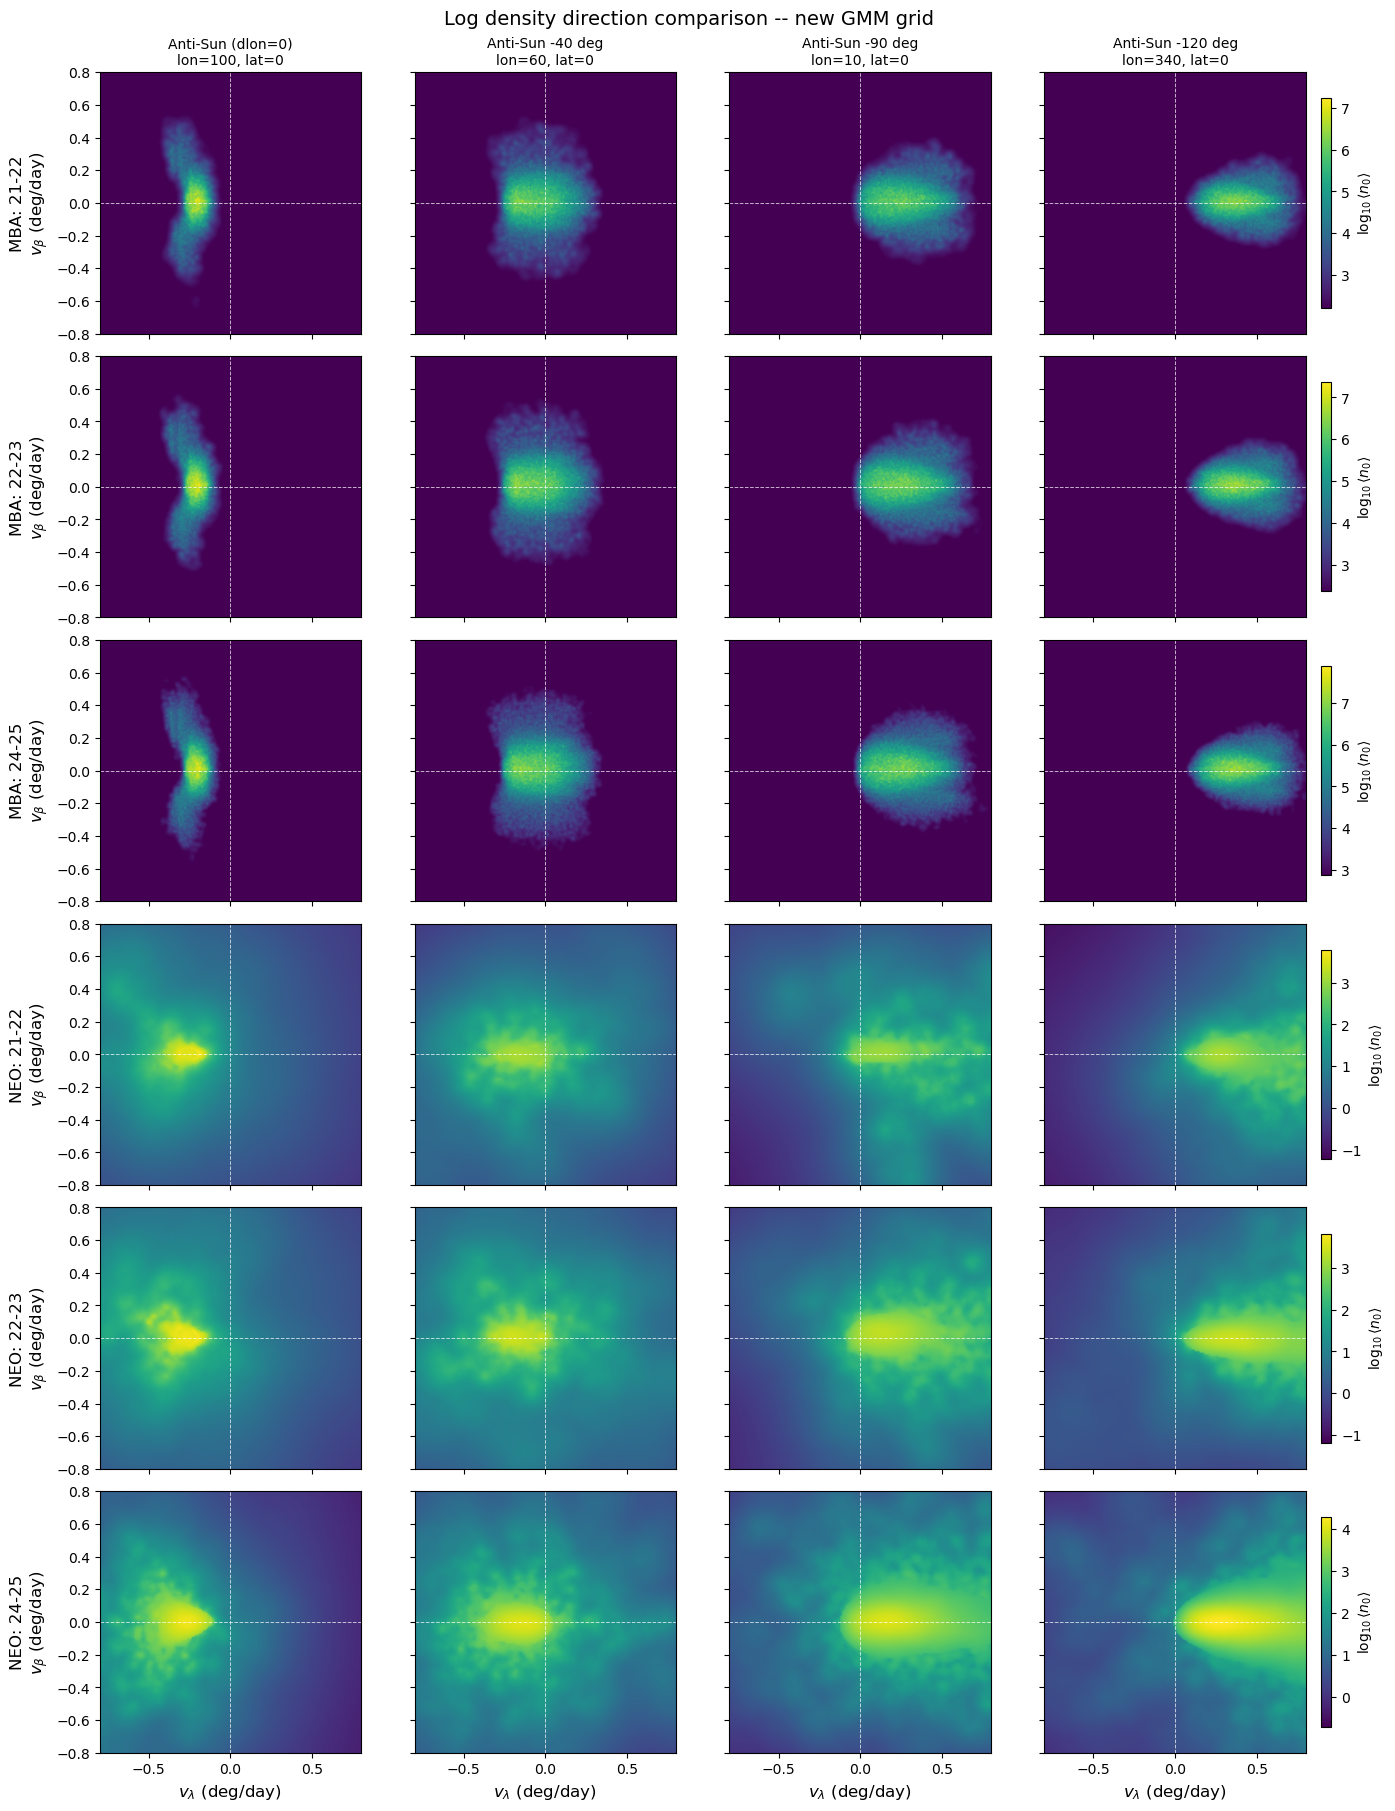

In [9]:
# 6x4 density grid: MBA then NEO, three mag bins, four directions
plot_direction_grid(dir_mapsets, pops=("MBA", "NEO"),
                    bins=["mag21", "mag22", "mag24+"], mode="density", figsize=(14, 18))

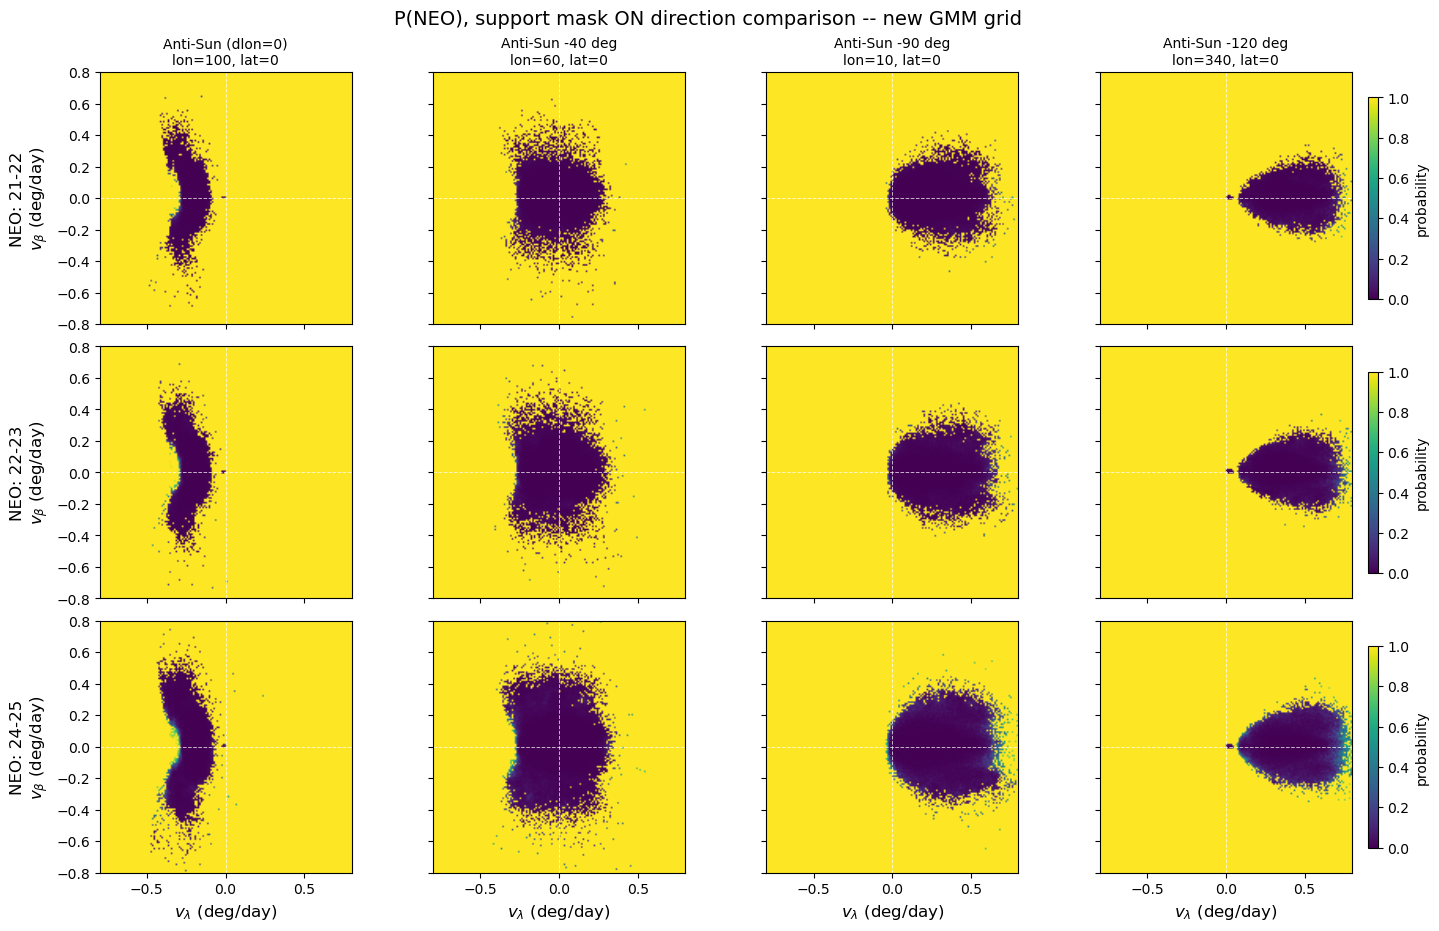

In [10]:
# 3x4 NEO probability grid (the key 'pure-NEO -> P~1' figure)
plot_direction_grid(dir_mapsets, pops=("NEO",),
                    bins=["mag21", "mag22", "mag24+"], mode="probability", figsize=(14.5, 9.2))

### Support mask OFF vs ON (antisun)

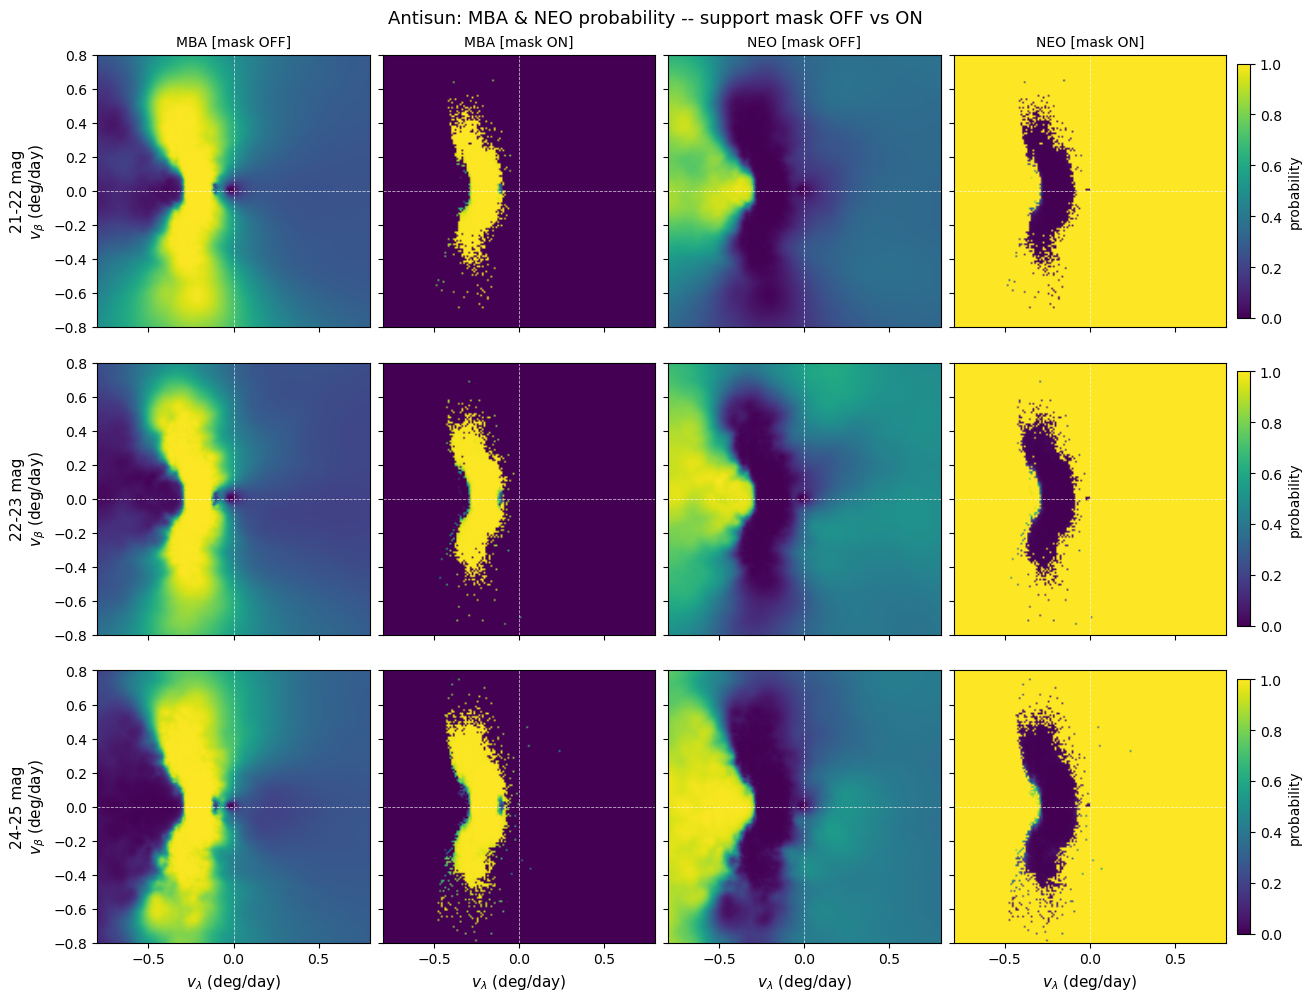

In [11]:
#support mask OFF vs ON, MBA & NEO probability (antisun direction) 
INF = float("inf")
ANTISUN = "prob_maps_grid_s3m/prob_maps_grid_dlon+000_lat+00.npz"
pm_off = vdp.ProbMapSet.from_npz(ANTISUN, mask_radius_deg_per_day=INF)                      # mask OFF
pm_on  = vdp.ProbMapSet.from_npz(ANTISUN, mask_radius_deg_per_day=INF, support_mask_min=1)  # mask ON
mc_bins = ["mag21", "mag22", "mag24+"]
mc_cols = [("MBA", pm_off, "MBA [mask OFF]"), ("MBA", pm_on, "MBA [mask ON]"),
           ("NEO", pm_off, "NEO [mask OFF]"), ("NEO", pm_on, "NEO [mask ON]")]
fig, ax = plt.subplots(len(mc_bins), 4, figsize=(13, 3.3 * len(mc_bins)),
                       sharex=True, sharey=True, constrained_layout=True)
for r, b in enumerate(mc_bins):
    im = None
    for c, (pop, pm, t) in enumerate(mc_cols):
        M = _clip(pm, pm.get_probability_map(b, pop))
        im = ax[r, c].imshow(M, origin="lower", extent=(*_VEL_LIM, *_VEL_LIM),
                             vmin=0, vmax=1, cmap="viridis", aspect="equal", interpolation="bilinear")
        ax[r, c].axvline(0, color="w", lw=.6, ls="--", alpha=.7); ax[r, c].axhline(0, color="w", lw=.6, ls="--", alpha=.7)
        if r == 0: ax[r, c].set_title(t, fontsize=10)
        if c == 0: ax[r, c].set_ylabel(f"{_mbd(b)} mag\n" + r"$v_\beta$ (deg/day)", fontsize=11)
        if r == len(mc_bins) - 1: ax[r, c].set_xlabel(r"$v_\lambda$ (deg/day)", fontsize=11)
    fig.colorbar(im, ax=ax[r, :], label="probability", shrink=0.85, pad=0.01)
fig.suptitle("Antisun: MBA & NEO probability -- support mask OFF vs ON", fontsize=13)
plt.show()

## 6. ROC curves — VDP vs digest2

Full sky and five elongation bands. Markers = best-F1 point.

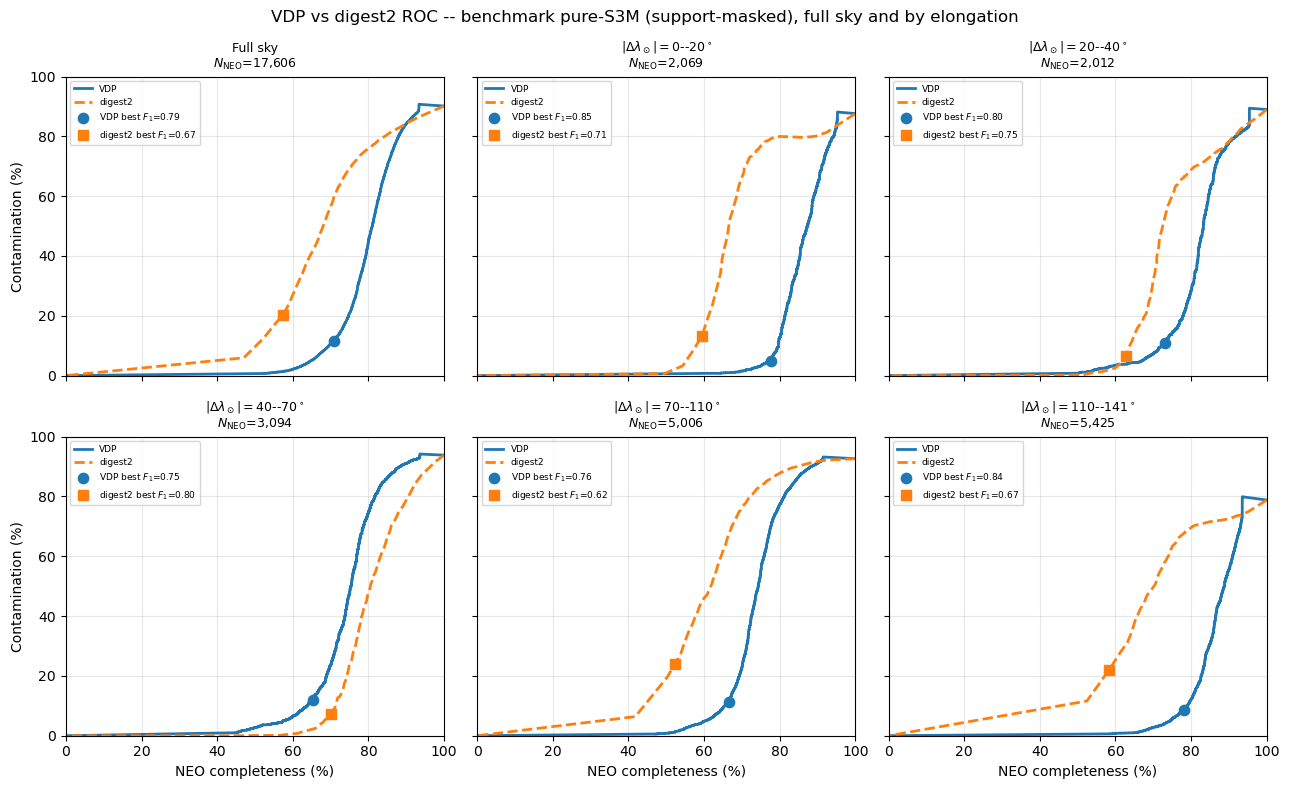

In [12]:
#  Figure: VDP vs digest2 ROC (completeness vs contamination) -- benchmark pure-S3M
def roc_xy(yy, s):
    p, r, t = precision_recall_curve(yy, s)
    f1 = np.divide(2 * p * r, p + r, out=np.zeros_like(p), where=(p + r) > 0)
    bi = int(np.argmax(f1[:-1]))
    return r * 100, (1 - p) * 100, f1[bi], r[bi] * 100, (1 - p[bi]) * 100

roc_panels = [("Full sky", np.ones(len(df), bool))]
for lo, hi in [(0, 20), (20, 40), (40, 70), (70, 110), (110, 141)]:
    roc_panels.append((rf"$|\Delta\lambda_\odot| = {lo}$--${hi}^\circ$",
                       ((df.absdlon >= lo) & (df.absdlon < hi)).to_numpy()))

fig, axes = plt.subplots(2, 3, figsize=(13, 8), sharex=True, sharey=True)
for ax, (title, m) in zip(axes.ravel(), roc_panels):
    yy = y[m]
    cv, kv, fv, mcv, mkv = roc_xy(yy, df.P_NEO_vdp.values[m])
    cd, kd, fd, mcd, mkd = roc_xy(yy, df.P_NEO_d2.values[m])
    ax.plot(cv, kv, lw=2, color="tab:blue", label="VDP")
    ax.plot(cd, kd, lw=2, color="tab:orange", ls="--", label="digest2")
    ax.scatter([mcv], [mkv], color="tab:blue", s=55, zorder=5, label=fr"VDP best $F_1$={fv:.2f}")
    ax.scatter([mcd], [mkd], color="tab:orange", s=55, marker="s", zorder=5, label=fr"digest2 best $F_1$={fd:.2f}")
    ax.set_title(fr"{title}" + "\n" + fr"$N_{{\rm NEO}}$={int(yy.sum()):,}", fontsize=9)
    ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.grid(alpha=0.3)
    ax.legend(fontsize=6.5, loc="upper left")
for ax in axes[-1, :]:
    ax.set_xlabel("NEO completeness (%)")
for ax in axes[:, 0]:
    ax.set_ylabel("Contamination (%)")
fig.suptitle("VDP vs digest2 ROC -- benchmark pure-S3M (support-masked), full sky and by elongation", fontsize=12)
plt.tight_layout()
plt.savefig("Figures/benchmark_roc_by_elongation.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:

# Summary table: best-F1 metrics per direction bin (VDP vs digest2)
def best_f1_metrics(yy, scores):
    p, r, t = precision_recall_curve(yy, scores)
    f1 = np.divide(2*p*r, p+r, out=np.zeros_like(p), where=(p+r)>0)
    bi = int(np.argmax(f1[:-1]))
    sel = scores >= t[bi]
    compl   = (sel & yy).sum() / max(yy.sum(), 1)
    contam  = (sel & ~yy).sum() / max(sel.sum(), 1)
    return f1[bi], compl, contam, t[bi]

rows = []
for title, m in roc_panels:
    yy = y[m]
    if yy.sum() < 30: continue
    fv, cv, kv, tv = best_f1_metrics(yy, df.P_NEO_vdp.values[m])
    fd, cd, kd, td = best_f1_metrics(yy, df.P_NEO_d2.values[m])
    rows.append({
        "Bin": title.replace(r"$|\Delta\lambda_\odot| = ", "|Δλ|=").replace(r"^\circ$", "°"),
        "N_NEO": int(yy.sum()),
        "N_total": int(m.sum()),
        "VDP F1":     round(fv, 3),
        "VDP compl":  f"{100*cv:.1f}%",
        "VDP contam": f"{100*kv:.1f}%",
        "VDP thresh": round(float(tv), 3),
        "d2 F1":      round(fd, 3),
        "d2 compl":   f"{100*cd:.1f}%",
        "d2 contam":  f"{100*kd:.1f}%",
        "d2 thresh":  round(float(td), 3),
    })

tbl = pd.DataFrame(rows)
print(tbl.to_string(index=False))
tbl.to_csv("outputs/benchmark_s3m_direction_bin_metrics.csv", index=False)
print("\nsaved outputs/benchmark_s3m_direction_bin_metrics.csv")


             Bin  N_NEO  N_total  VDP F1 VDP compl VDP contam  VDP thresh  d2 F1 d2 compl d2 contam  d2 thresh
        Full sky  17606   178398   0.787     70.9%      11.7%       0.019  0.667    57.4%     20.4%       0.97
   |Δλ|=0$--$20°   2069    16701   0.854     77.6%       5.0%       0.177  0.706    59.4%     13.1%       0.97
  |Δλ|=20$--$40°   2012    18235   0.803     73.2%      11.1%       0.011  0.750    62.7%      6.5%       0.92
  |Δλ|=40$--$70°   3094    50017   0.750     65.3%      11.9%       0.010  0.799    70.1%      7.1%       0.71
 |Δλ|=70$--$110°   5006    67835   0.760     66.5%      11.3%       0.014  0.620    52.3%     24.0%       0.97
|Δλ|=110$--$141°   5425    25610   0.842     78.0%       8.5%       0.019  0.667    58.3%     21.9%       0.99

saved outputs/benchmark_s3m_direction_bin_metrics.csv


## 7. Mega-grid — density and P across elongation (mag 24–25)

Rows: MBA/NEO log density, P mask OFF, P mask ON. Columns: Δλ = 0°, −30°, −50°, −90°, −120°.

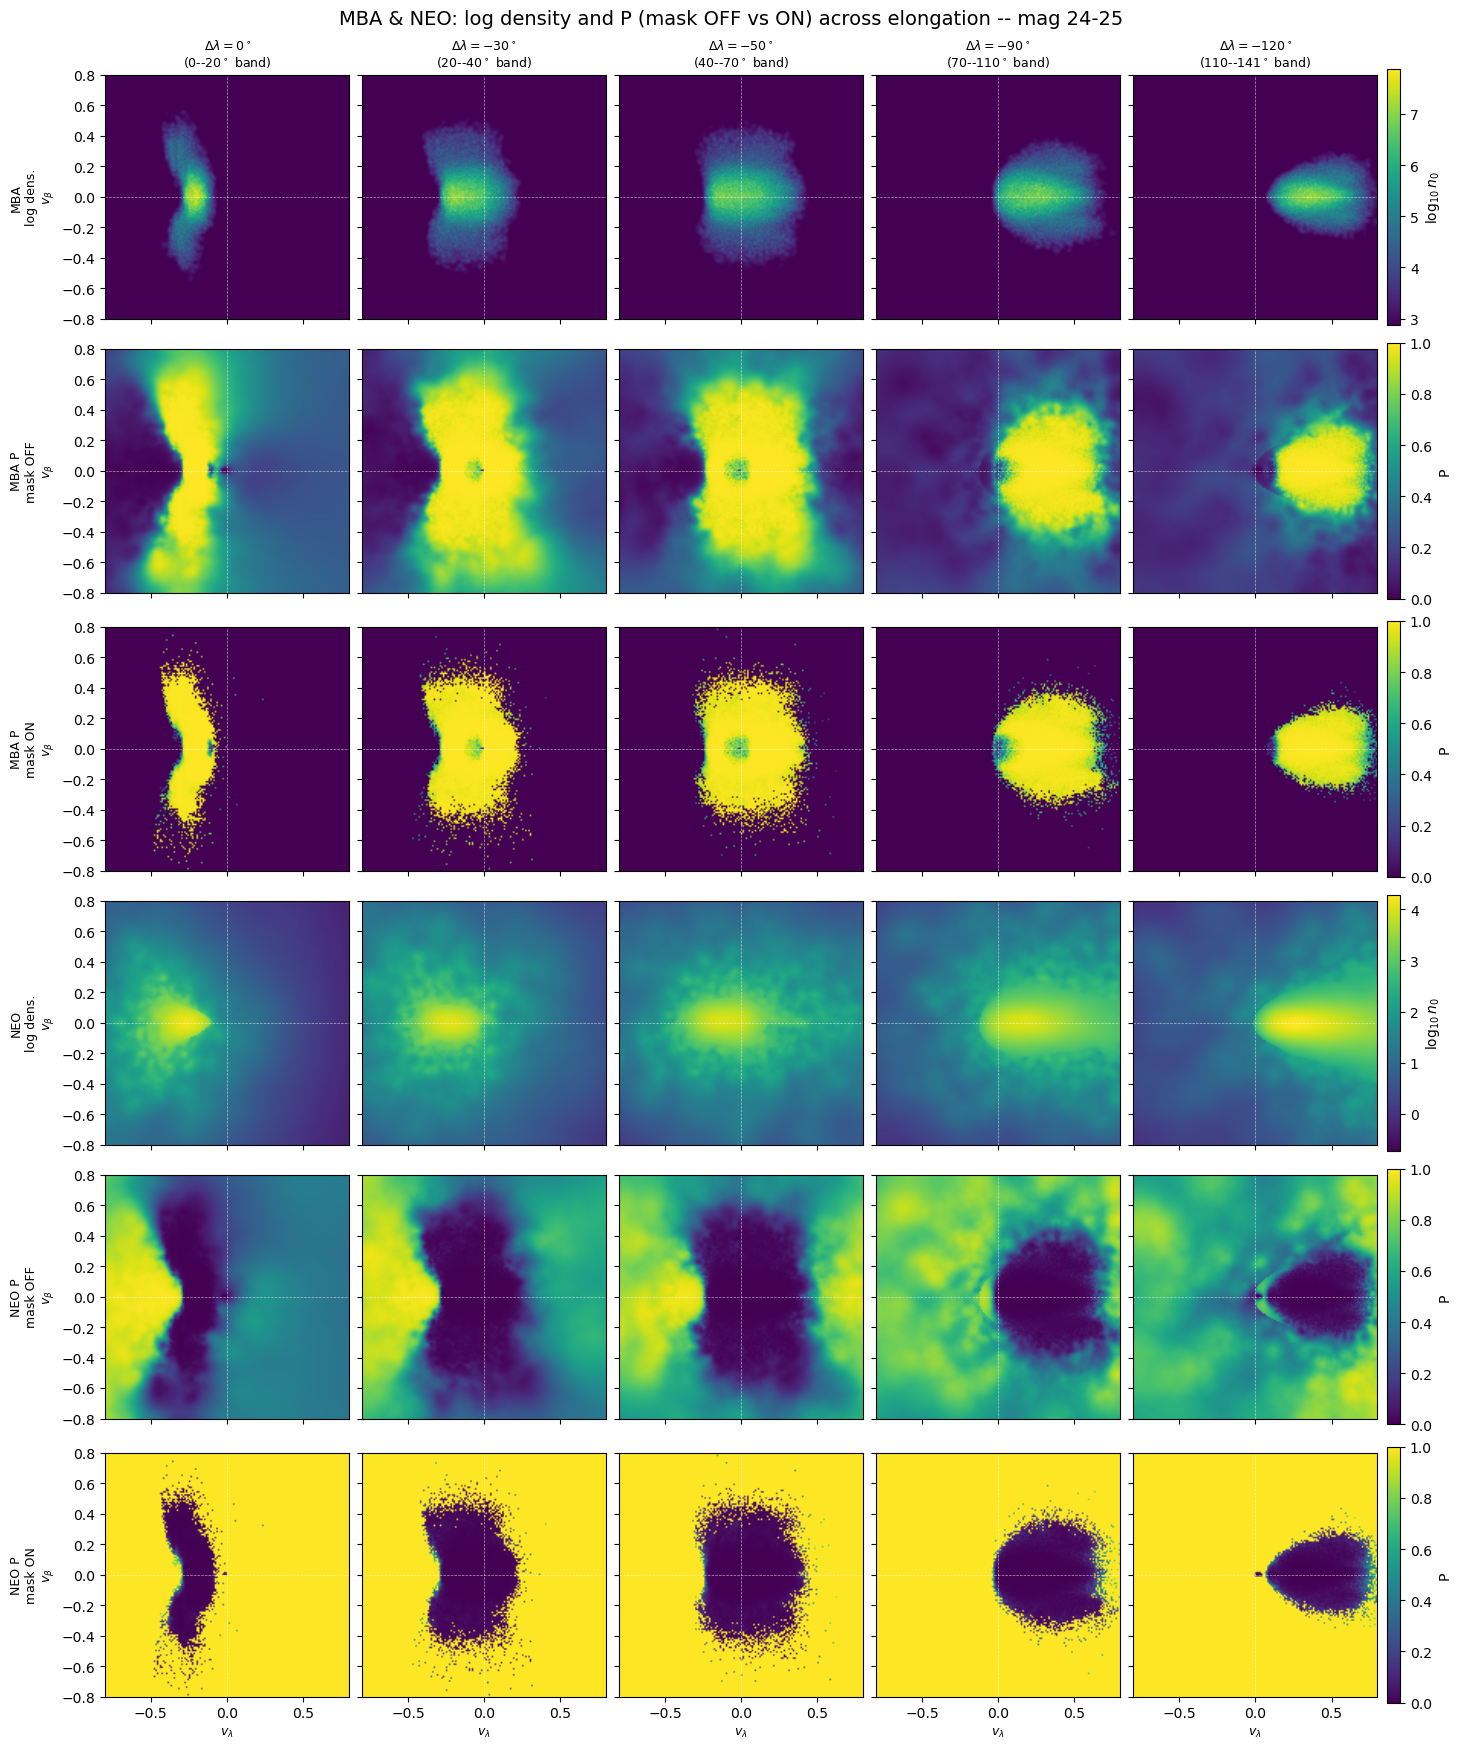

In [14]:
# Mega-grid: MBA & NEO log density + P(mask OFF/ON) across elongation, mag 24-25 
MG_BIN = "mag24+"
MG_DIRS = [("0", "0--20", "dlon+000"), ("-30", "20--40", "dlon-030"), ("-50", "40--70", "dlon-050"),
           ("-90", "70--110", "dlon-090"), ("-120", "110--141", "dlon-120")]
mg_off = [vdp.ProbMapSet.from_npz(f"prob_maps_grid_s3m/prob_maps_grid_{d}_lat+00.npz",
                                  mask_radius_deg_per_day=float("inf")) for *_, d in MG_DIRS]
mg_on  = [vdp.ProbMapSet.from_npz(f"prob_maps_grid_s3m/prob_maps_grid_{d}_lat+00.npz",
                                  mask_radius_deg_per_day=float("inf"), support_mask_min=1) for *_, d in MG_DIRS]
mg_rows = [("MBA", "density"), ("MBA", "off"), ("MBA", "on"),
           ("NEO", "density"), ("NEO", "off"), ("NEO", "on")]
mg_rl = {("MBA", "density"): "MBA\nlog dens.", ("MBA", "off"): "MBA P\nmask OFF", ("MBA", "on"): "MBA P\nmask ON",
         ("NEO", "density"): "NEO\nlog dens.", ("NEO", "off"): "NEO P\nmask OFF", ("NEO", "on"): "NEO P\nmask ON"}
nc = len(MG_DIRS)
fig, ax = plt.subplots(len(mg_rows), nc, figsize=(2.9 * nc, 2.9 * len(mg_rows)),
                       sharex=True, sharey=True, constrained_layout=True)
for r, (pop, kind) in enumerate(mg_rows):
    rd = []
    for c in range(nc):
        if kind == "density":
            rd.append(_density_log_map(_clip(mg_off[c], mg_off[c].results[MG_BIN]["density_maps_downweighted_raw"][pop]))[0])
        elif kind == "off":
            rd.append(_clip(mg_off[c], mg_off[c].get_probability_map(MG_BIN, pop)))
        else:
            rd.append(_clip(mg_on[c], mg_on[c].get_probability_map(MG_BIN, pop)))
    if kind == "density":
        sup = [d for d in rd if np.ma.count(d) > 0]
        vmax = max(float(np.nanmax(d)) for d in sup) if sup else 1.0
        vmin = vmax - 5; cmap = _density_cmap(); cbl = r"$\log_{10} n_0$"
    else:
        vmin, vmax = 0, 1; cmap = "viridis"; cbl = "P"
    im = None
    for c in range(nc):
        a = ax[r, c]
        im = a.imshow(rd[c], origin="lower", extent=(*_VEL_LIM, *_VEL_LIM), vmin=vmin, vmax=vmax,
                      cmap=cmap, aspect="equal", interpolation="bilinear")
        a.axvline(0, color="w", lw=.5, ls="--", alpha=.6); a.axhline(0, color="w", lw=.5, ls="--", alpha=.6)
        if r == 0:
            a.set_title(fr"$\Delta\lambda={MG_DIRS[c][0]}^\circ$" + "\n" + fr"({MG_DIRS[c][1]}$^\circ$ band)", fontsize=9)
        if c == 0:
            a.set_ylabel(mg_rl[(pop, kind)] + "\n" + r"$v_\beta$", fontsize=9)
        if r == len(mg_rows) - 1:
            a.set_xlabel(r"$v_\lambda$", fontsize=9)
    fig.colorbar(im, ax=ax[r, :], fraction=.012, pad=.008, label=cbl)
fig.suptitle("MBA & NEO: log density and P (mask OFF vs ON) across elongation -- mag 24-25", fontsize=14)
plt.show()

## 8. ROC grid — elongation × magnitude

Rows: five elongation bands. Columns: all mags, 21–22, 22–23, 24–25.

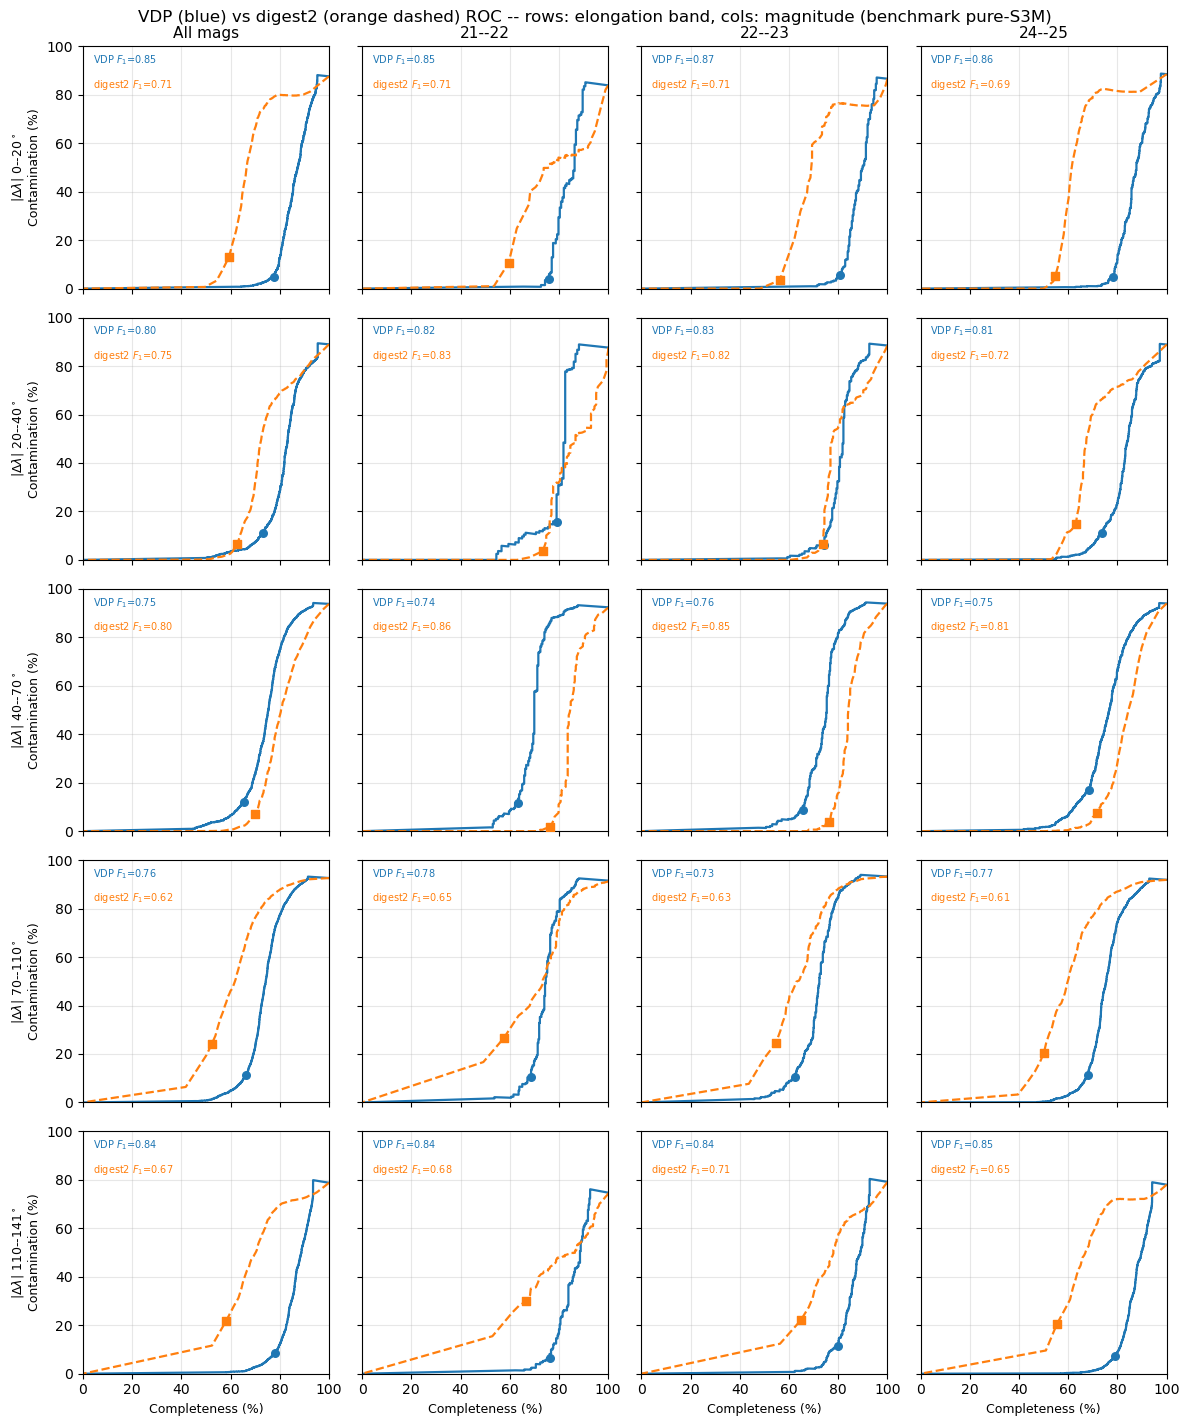

In [15]:
# ROC grid: elongation band (rows) x magnitude (cols) -- benchmark pure-S3M
from sklearn.metrics import precision_recall_curve

def _roc_panel(ax, yy, sv, sd):
    if yy.sum() < 30 or (~yy).sum() < 30:
        ax.text(0.5, 0.5, f"$N_{{\\rm NEO}}$={int(yy.sum())}\n(too few)",
                transform=ax.transAxes, ha="center", va="center", fontsize=8, color="0.4")
        return
    for s, col, ls, mk, lab, ytx in [(sv, "tab:blue", "-", "o", "VDP", 0.93),
                                      (sd, "tab:orange", "--", "s", "digest2", 0.83)]:
        p, r, t = precision_recall_curve(yy, s)
        f1 = np.divide(2*p*r, p+r, out=np.zeros_like(p), where=(p+r) > 0)
        bi = int(np.argmax(f1[:-1]))
        ax.plot(r*100, (1-p)*100, lw=1.6, color=col, ls=ls)
        ax.scatter([r[bi]*100], [(1-p[bi])*100], color=col, s=30, marker=mk, zorder=5)
        ax.text(0.04, ytx, f"{lab} $F_1$={f1[bi]:.2f}", transform=ax.transAxes,
                fontsize=7, color=col)

_BANDS = [(0,20,"0--20"),(20,40,"20--40"),(40,70,"40--70"),(70,110,"70--110"),(110,141,"110--141")]
_COLS  = [("All mags", None), ("21--22","mag21"), ("22--23","mag22"), ("24--25","mag24+")]

fig, ax = plt.subplots(len(_BANDS), len(_COLS), figsize=(12, 14.5), sharex=True, sharey=True)
for ri, (lo, hi, bl) in enumerate(_BANDS):
    bm = (df.absdlon >= lo) & (df.absdlon < hi)
    for ci, (ml, mb) in enumerate(_COLS):
        m = (bm & (df.mag_bin_label == mb)).to_numpy() if mb else bm.to_numpy()
        _roc_panel(ax[ri, ci], y[m], df.P_NEO_vdp.values[m], df.P_NEO_d2.values[m])
        a = ax[ri, ci]
        a.set_xlim(0, 100); a.set_ylim(0, 100); a.grid(alpha=0.3)
        if ri == 0:               a.set_title(ml, fontsize=11)
        if ci == 0:               a.set_ylabel(f"$|\\Delta\\lambda|$ {bl}$^\\circ$\nContamination (%)", fontsize=9)
        if ri == len(_BANDS)-1:   a.set_xlabel("Completeness (%)", fontsize=9)
fig.suptitle("VDP (blue) vs digest2 (orange dashed) ROC -- rows: elongation band, cols: magnitude (benchmark pure-S3M)",
             fontsize=12)
plt.tight_layout()
plt.show()

## 9. Benchmark tracklet distribution in rate space

Where actual benchmark tracklets land in (v_λ, v_β) per elongation band. NEO top row, MBA bottom row.

/tmp/ipykernel_1577152/2331578277.py:33: RuntimeWarning: divide by zero encountered in log10
  Lh = np.where(H > 0, np.log10(H), np.nan)


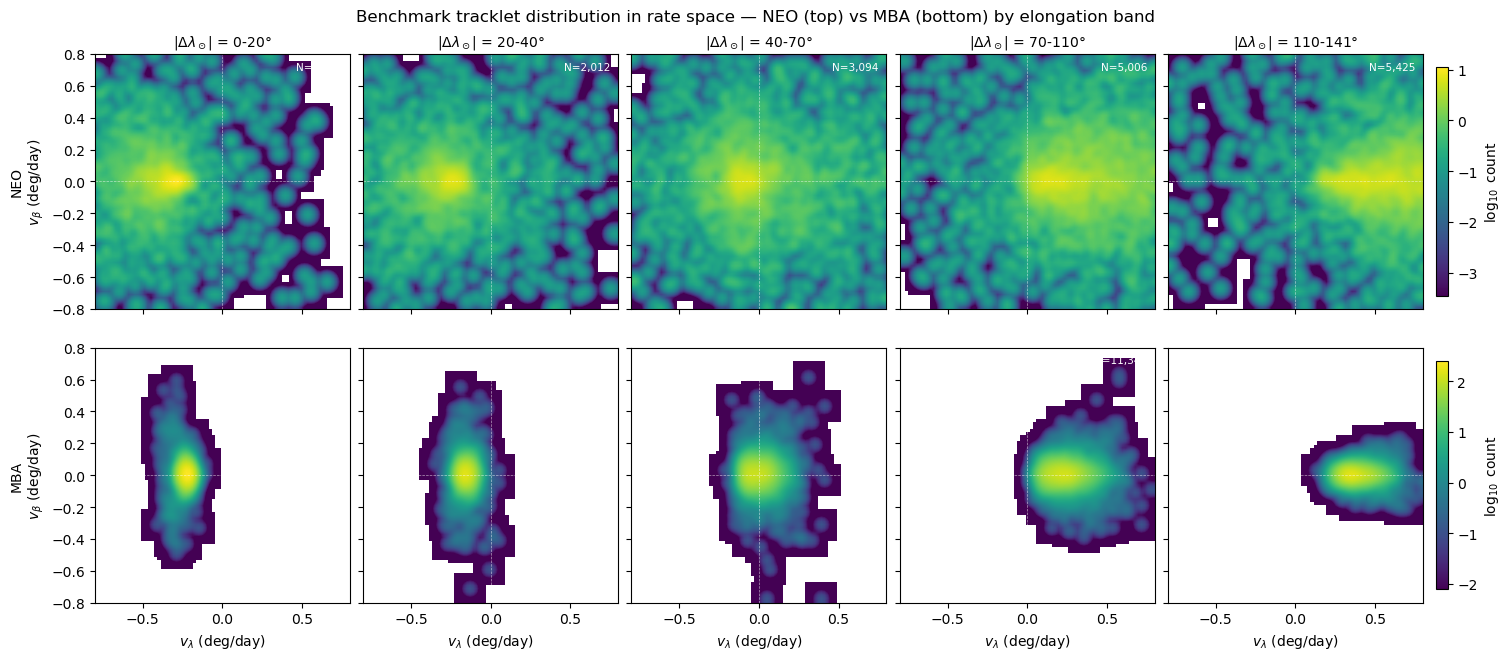

saved Figures/benchmark_tracklet_ratespace_by_elongation.png


In [16]:

from scipy.ndimage import gaussian_filter

BANDS = [(0, 20,  "0-20°"),
         (20, 40, "20-40°"),
         (40, 70, "40-70°"),
         (70, 110,"70-110°"),
         (110,141,"110-141°")]
VLIM  = 0.8
BINS  = 80
SIGMA = 1.2

edges = np.linspace(-VLIM, VLIM, BINS + 1)

fig, axes = plt.subplots(2, len(BANDS), figsize=(15, 6.5),
                         sharex=True, sharey=True, constrained_layout=True)

for ri, (pop_label, pop_key) in enumerate([("NEO", "NEO"), ("MBA", "MBA")]):
    pop_mask = df.aligned.values == pop_key

    hists, counts = [], []
    for lo, hi, _ in BANDS:
        m = pop_mask & (df.absdlon.values >= lo) & (df.absdlon.values < hi)
        H, _, _ = np.histogram2d(df.vlam.values[m], df.vbeta.values[m], bins=edges)
        hists.append(gaussian_filter(H.astype(float), sigma=SIGMA))
        counts.append(int(m.sum()))

    row_max = max(H.max() for H in hists if H.max() > 0)
    vmax = np.log10(row_max)
    vmin = vmax - 4.5

    for ci, ((lo, hi, band_label), H, n) in enumerate(zip(BANDS, hists, counts)):
        ax = axes[ri, ci]
        Lh = np.where(H > 0, np.log10(H), np.nan)
        im = ax.imshow(Lh.T, origin="lower",
                       extent=(-VLIM, VLIM, -VLIM, VLIM),
                       aspect="equal", cmap="viridis",
                       vmin=vmin, vmax=vmax, interpolation="bilinear")
        ax.axvline(0, color="w", lw=0.5, ls="--", alpha=0.6)
        ax.axhline(0, color="w", lw=0.5, ls="--", alpha=0.6)
        ax.text(0.97, 0.97, f"N={n:,}", transform=ax.transAxes,
                ha="right", va="top", fontsize=7.5, color="white")
        if ri == 0: ax.set_title(fr"$|\Delta\lambda_\odot|$ = {band_label}", fontsize=10)
        if ci == 0: ax.set_ylabel(f"{pop_label}\n" + r"$v_\beta$ (deg/day)", fontsize=10)
        if ri == 1: ax.set_xlabel(r"$v_\lambda$ (deg/day)", fontsize=10)

    fig.colorbar(im, ax=axes[ri, :], label=r"$\log_{10}$ count", shrink=0.8, pad=0.01)

fig.suptitle("Benchmark tracklet distribution in rate space — NEO (top) vs MBA (bottom) by elongation band",
             fontsize=12)
plt.savefig("Figures/benchmark_tracklet_ratespace_by_elongation.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved Figures/benchmark_tracklet_ratespace_by_elongation.png")


## 10. Direction comparison maps — all four populations (MBA, NEO, TNO, Trojans)

Same grid as Section 5 but including TNOs and Trojans. Shows how each population's velocity distribution shifts with sky direction, and why slow-moving populations (TNO, Trojans) land near the map centre regardless of direction — explaining VDP's robustness to contamination.

In [ ]:
# All four populations — log density across four directions, three mag bins
# dir_mapsets and helper functions defined in Section 5 (cell b2126b9c)
_POPS4 = ("MBA", "NEO", "TNO", "Trojans")
_BINS3 = ["mag21", "mag22", "mag24+"]
_rows  = [(p, b) for p in _POPS4 for b in _BINS3]   # 12 rows
_items = list(dir_mapsets.items())                    # 4 columns

fig, ax = plt.subplots(len(_rows), len(_items), figsize=(14, 36),
                       sharex=True, sharey=True, constrained_layout=True)
ax = np.atleast_2d(ax)

for r, (pop, b) in enumerate(_rows):
    rd = [_dir_map_data(pm, pop, b, "density") for _, pm in _items]
    sup = [d for d in rd if np.ma.count(d) > 0]
    vmax = max(float(np.nanmax(d)) for d in sup) if sup else 1.0
    vmin = vmax - 5.0
    im = None
    for c, ((dl, pm), d) in enumerate(zip(_items, rd)):
        a = ax[r, c]
        im = a.imshow(d, origin="lower", extent=(*_VEL_LIM, *_VEL_LIM),
                      cmap=_density_cmap(), vmin=vmin, vmax=vmax,
                      interpolation="bilinear", aspect="equal")
        a.axvline(0, color="w", lw=.7, ls="--", alpha=.7)
        a.axhline(0, color="w", lw=.7, ls="--", alpha=.7)
        _annotate_no_support(a, d)
        if r == 0:
            a.set_title(f"{dl}\nlon={pm.center_lon_deg:.0f}, lat={pm.center_lat_deg:.0f}", fontsize=10)
        if c == 0:
            a.set_ylabel(f"{pop}: {_mbd(b)}\n" + r"$v_\beta$ (deg/day)", fontsize=11)
        if r == len(_rows) - 1:
            a.set_xlabel(r"$v_\lambda$ (deg/day)", fontsize=12)
    fig.colorbar(im, ax=ax[r, :], label=r"$\log_{10}\langle n_0\rangle$", shrink=0.8, pad=0.012)

fig.suptitle("Log density direction comparison — MBA / NEO / TNO / Trojans across four sky directions\n"
             "TNOs and Trojans cluster near origin regardless of direction → VDP assigns low P(NEO)",
             fontsize=13)
plt.savefig("Figures/benchmark_allpops_direction_density.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved Figures/benchmark_allpops_direction_density.png")